### 1. Running the model

In [ ]:
using Plots
include("carbon_model.jl")
include("solver.jl")
include("sensitivity.jl")

# 3 box carbon model
C0 = [Ca0, Cs0, Cd0]
tspan = (0.0, 200.0) # simulating over 200 years
dt = 1.0 # time step

# Solving with two solvers...
tE, CE = euler_solver(carbon_system, C0, tspan, dt)
tR, CR = rk4_solver(carbon_system, C0, tspan, dt);

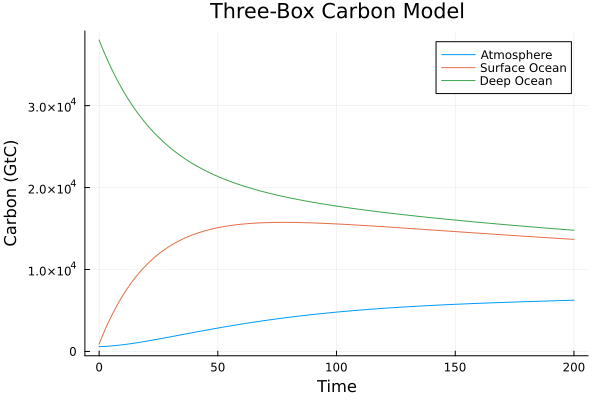

In [113]:
# Plot the results for surface ocean, atm, and deep ocean
plot(tR, CR[1, :],
    label = "Atmosphere", xlabel = "Time", ylabel = "Carbon (GtC)",
    title = "Three-Box Carbon Model")
plot!(tR, CR[2, :],
    label = "Surface Ocean")
plot!(tR, CR[3, :],
    label = "Deep Ocean")

In [ ]:
# Results
println("\nFinal atm CO2 at end of 200 yr sim period")
println("Euler final CO2 (ppm): ", CE[1, end] / 2.12)
println("RK4 final CO2 (ppm):   ", CR[1, end] / 2.12)
println("That's high!! Upper end estimates for 2150 are usually <2000 ppm (Meinshausen et al. (2020), Geoscientific Model Development)")


Final atm CO2 at end of 200 yr sim period
Euler final CO2 (ppm): 2951.548900643543
RK4 final CO2 (ppm):   2947.7600845615607
That's high!! Upper end estimates for 2150 are usually <2000 ppm (Meinshausen et al. (2020), Geoscientific Model Development)


### 2. Sensitivity Analysis

In [116]:
# experiment 1: vary atm-surface ocean exchange (kas), hold surface-deep ocean
kas_vals = collect(0.05:0.02:0.25)
ksd_fixed = 0.05 # this is fixed
kas_results = sensitivity_kas(kas_vals, ksd_fixed)

# experiment 2: vary surface-deep ocean, hold atm-surface ocean
ksd_vals = collect(0.02:0.01:0.10)
kas_fixed = 0.12
ksd_results = sensitivity_ksd(ksd_vals, kas_fixed);

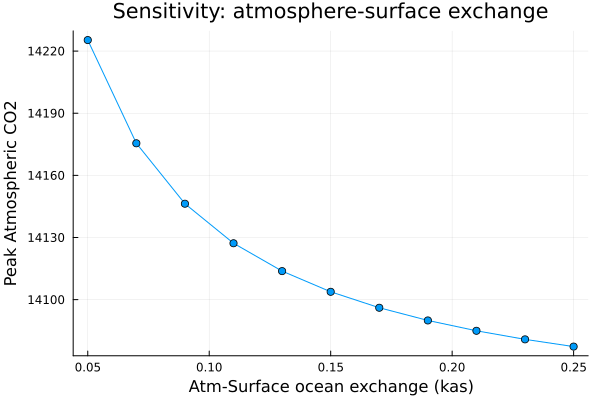

In [117]:
# Exp 1: Kas varying
kas_vals_plot = [r[1] for r in kas_results]
kas_peaks = [maximum(r[3][1, :]) for r in kas_results]

plot(kas_vals_plot, kas_peaks,
    xlabel = "Atm-Surface ocean exchange (kas)",
    ylabel = "Peak Atmospheric CO2",
    title = "Sensitivity: atmosphere-surface exchange",
    marker = :circle,
    label = false)


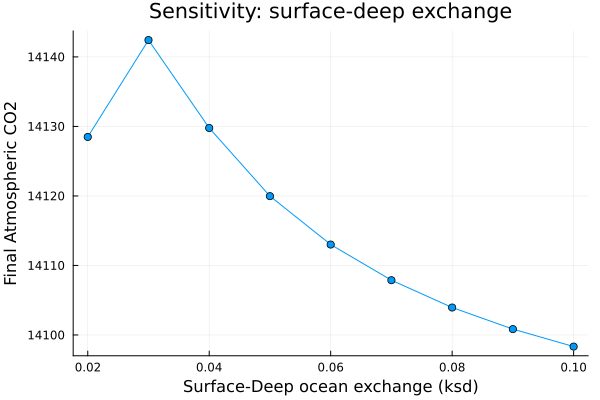

In [ ]:
# Exp 2: ksd
# Looks weird! I think one of the eqns is being divided by 0 at 0.03 ksd
ksd_vals_plot = [r[1] for r in ksd_results]
ksd_final = [r[3][1, end] for r in ksd_results]

plot(ksd_vals_plot, ksd_final,
    xlabel = "Surface-Deep ocean exchange (ksd)",
    ylabel = "Final Atmospheric CO2",
    title = "Sensitivity: surface-deep exchange",
    marker = :circle,
    label = false)

### 3. Monte Carlo sim 

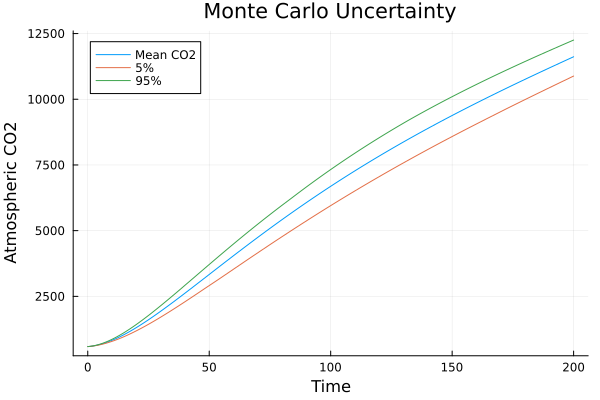

In [119]:
using Statistics
# MC analysis , simulate the model with perturbed param values
t_mc, Ca_mc = monte_carlo_runs(100)
mean_path = vec(mean(Ca_mc, dims=1))
lower = [quantile(Ca_mc[:,i], 0.05)
         for i in 1:length(t_mc)]
upper = [quantile(Ca_mc[:,i], 0.95)
         for i in 1:length(t_mc)]

plot(t_mc, mean_path, label="Mean CO2", xlabel="Time",
    ylabel="Atmospheric CO2", title="Monte Carlo Uncertainty")
plot!(t_mc, lower, label="5%")
plot!(t_mc, upper, label="95%")